<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Memahami tujuan bisnis dan menyiapkan environment

## Import library utama

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## Import XGBoost dan atur tampilan awal

In [2]:
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Upload dataset ke Google Colab

In [3]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


## Membaca dataset ke DataFrame

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Melihat ukuran dataset dan nama kolom

In [5]:
print("Shape dataset:", df.shape)
print("\nDaftar Kolom")
print(df.columns.tolist())

Shape dataset: (7043, 21)

Daftar Kolom
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Memahami informasi umum dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Melihat target yang akan diprediksi

In [7]:
print(df["Churn"].value_counts())
print("\nProporsi Target:")
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi Target:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


## Visualisasi distribusi target churn

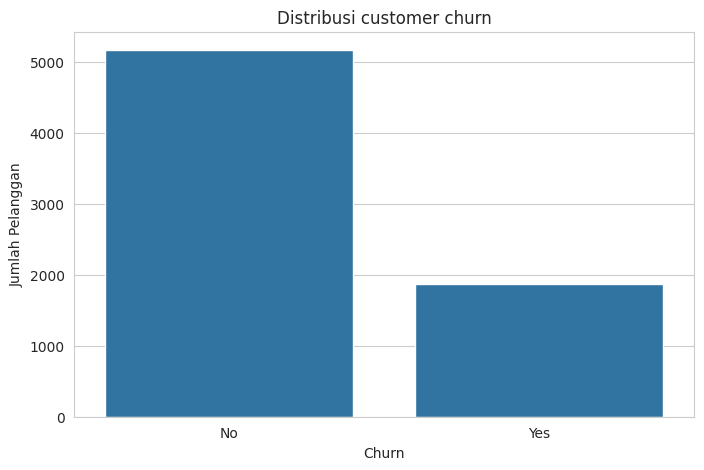

In [8]:
sns.countplot(data=df, x="Churn")
plt.title("Distribusi customer churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.show()

# Fase 2: Memahami data dan melakukan eksplorasi awal

## Meninjau ulang sampel data

In [9]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Melihat beberapa baris terakhir dataset

In [10]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Statistik ringkas untuk kolom numerik

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Statistik ringkas untuk semua kolom termasuk kategorikal

In [12]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## Mengecek missing values yang terlihat jelas

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Mengecek nilai kosong tersembunyi berupa string kosong atau spasi

In [14]:
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Mengecek spasi kosong pada semua kolom bertipe object

In [15]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
  print(f"Kolom {col}:")
  print(df[col].astype(str).str.strip().eq("").sum())
  print("-" * 30)

Kolom customerID:
0
------------------------------
Kolom gender:
0
------------------------------
Kolom Partner:
0
------------------------------
Kolom Dependents:
0
------------------------------
Kolom PhoneService:
0
------------------------------
Kolom MultipleLines:
0
------------------------------
Kolom InternetService:
0
------------------------------
Kolom OnlineSecurity:
0
------------------------------
Kolom OnlineBackup:
0
------------------------------
Kolom DeviceProtection:
0
------------------------------
Kolom TechSupport:
0
------------------------------
Kolom StreamingTV:
0
------------------------------
Kolom StreamingMovies:
0
------------------------------
Kolom Contract:
0
------------------------------
Kolom PaperlessBilling:
0
------------------------------
Kolom PaymentMethod:
0
------------------------------
Kolom TotalCharges:
11
------------------------------
Kolom Churn:
0
------------------------------


## Mengecek data duplikat

In [16]:
print("Jumlah baris duplikat", df.duplicated().sum())

Jumlah baris duplikat 0


## Melihat nilai unik pada beberapa kolom penting

In [17]:
important_cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']

for col in important_cat_cols:
  print(f"Kolom {col}:")
  print(df[col].unique())
  print("-" * 50)

Kolom gender:
['Female' 'Male']
--------------------------------------------------
Kolom Partner:
['Yes' 'No']
--------------------------------------------------
Kolom Dependents:
['No' 'Yes']
--------------------------------------------------
Kolom PhoneService:
['No' 'Yes']
--------------------------------------------------
Kolom InternetService:
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
Kolom Contract:
['Month-to-month' 'One year' 'Two year']
--------------------------------------------------
Kolom PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
--------------------------------------------------
Kolom Churn:
['No' 'Yes']
--------------------------------------------------


## Memisahkan kolom numerik dan kategorikal

In [18]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Kolom numerik:", numerical_cols)
print("\nKolom kategorikal:", categorical_cols)

Kolom numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Kolom kategorikal: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


## Visualisasi churn berdasarkan jenis kontrak

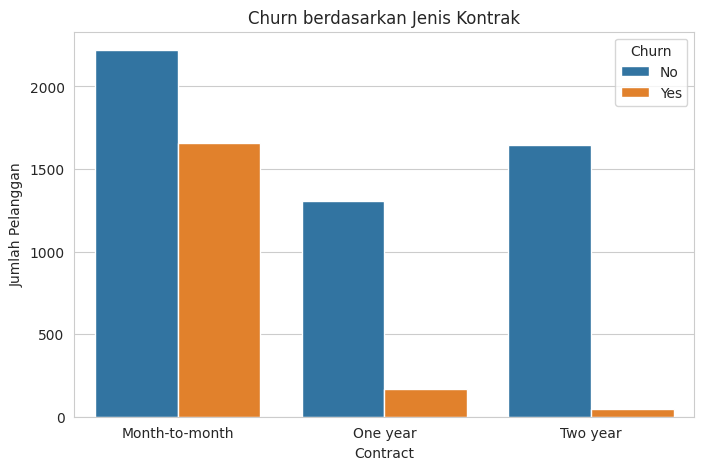

In [19]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn berdasarkan Jenis Kontrak')
plt.xlabel('Contract')
plt.ylabel('Jumlah Pelanggan')
plt.show()

## Visualisasi tenure terhadap churn

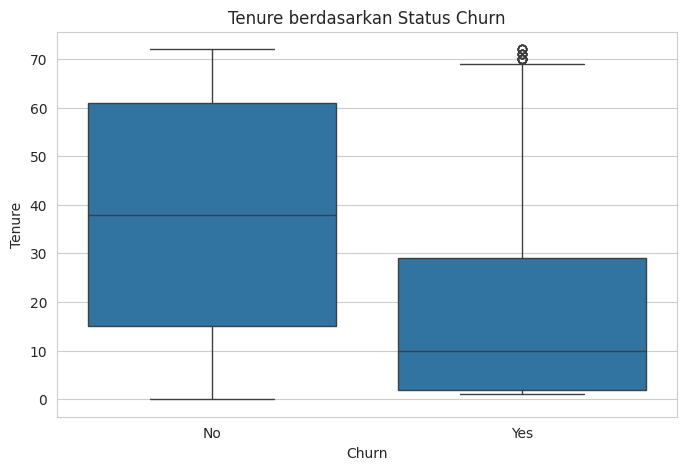

In [20]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure berdasarkan Status Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

## Visualisasi MonthlyCharges terhadap churn

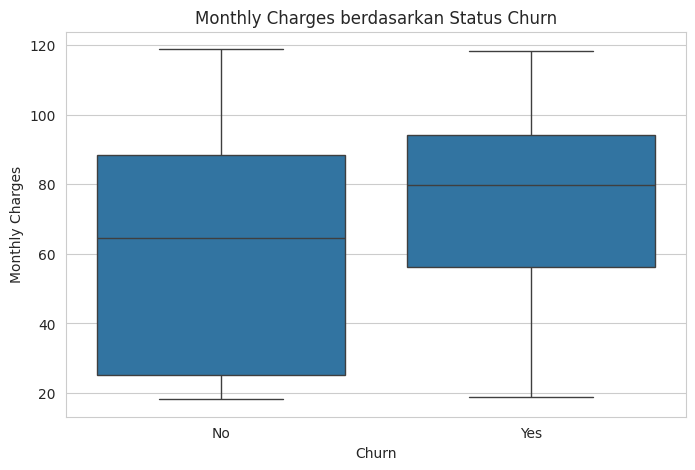

In [21]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges berdasarkan Status Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

# Fase 3: Data cleaning dan preprocessing

## Membuat salinan dataset kerja

In [22]:
df_clean = df.copy()
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Menghapus kolom yang tidak berguna untuk model

In [23]:
df_clean = df_clean.drop(columns="customerID")
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Memeriksa kolom TotalCharges yang sering bermasalah

In [24]:
print(df_clean['TotalCharges'].dtype)
print(df_clean['TotalCharges'].head(10))

object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


## Membersihkan spasi kosong pada TotalCharges dan mengubah ke numerik

In [25]:
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(" ", np.nan)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'])
df_clean['TotalCharges'].dtype

dtype('float64')

## Mengecek missing values setelah perbaikan tipe data

In [26]:
df_clean.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Menangani missing values

In [27]:
df_clean = df_clean.dropna()
print('Shape setelah drop missing values:', df_clean.shape)

Shape setelah drop missing values: (7032, 20)


## Mengecek dan menghapus duplikasi jika ada

In [28]:
print('Jumlah duplicated sebelum dihapus:', df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()
print('Jumlah duplicated setelah dihapus:', df_clean.duplicated().sum())
print('Jumlah shape dataset setelah penghapusan duplicated:', df_clean.shape)

Jumlah duplicated sebelum dihapus: 22
Jumlah duplicated setelah dihapus: 0
Jumlah shape dataset setelah penghapusan duplicated: (7010, 20)


## Memisahkan fitur dan target

In [29]:
X = df_clean.drop(columns="Churn")
y = df_clean["Churn"]

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (7010, 19)
Shape y: (7010,)


## Mengubah target Churn menjadi numerik

In [30]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())
print(y.head())

Churn
0    5153
1    1857
Name: count, dtype: int64
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


## Mengidentifikasi kolom numerik dan kategorikal dari fitur

In [31]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print('Fitur numerik:', numeric_features)
print('Fitur kategorikal:', categorical_features)

Fitur numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Fitur kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Membagi data latih dan data uji

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (5608, 19)
Shape X_test : (1402, 19)
Shape y_train: (5608,)
Shape y_test : (1402,)


## Membuat pipeline preprocessing

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

## Mendefinisikan preprocessing untuk fitur numerik dan kategorikal

In [34]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## Menggabungkan preprocessing dalam ColumnTransformer

In [35]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Menjalankan preprocessing pada data latih dan data uji

In [36]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape X_train_processed:", X_train_processed.shape)
print("Shape X_test_processed :", X_test_processed.shape)

Shape X_train_processed: (5608, 45)
Shape X_test_processed : (1402, 45)


# Fase 4: Membangun model baseline dan evaluasi awal

## Import model baseline dan metrik evaluasi

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Membuat model baseline logistic regression

In [38]:
baseline_model = LogisticRegression(max_iter=5000, random_state=42)
baseline_model

LogisticRegression(max_iter=5000, random_state=42)

## Melatih model baseline

In [39]:
baseline_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=5000, random_state=42)

## Melakukan prediksi pada data uji

In [40]:
y_pred_baseline = baseline_model.predict(X_test_processed)
y_pred_baseline[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Menghitung accuracy, precision, recall, dan F1-score

In [41]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Accuracy  :", baseline_accuracy)
print("Precission:", baseline_precision)
print("Recall    :", baseline_recall)
print("f1        :", baseline_f1)

Accuracy  : 0.8074179743223966
Precission: 0.6688963210702341
Recall    : 0.5390835579514824
f1        : 0.5970149253731343


## Menampilkan classification report

In [42]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



## Membuat confusion matrix

In [43]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_baseline

array([[932,  99],
       [171, 200]])

## Visualisasi confusion matrix

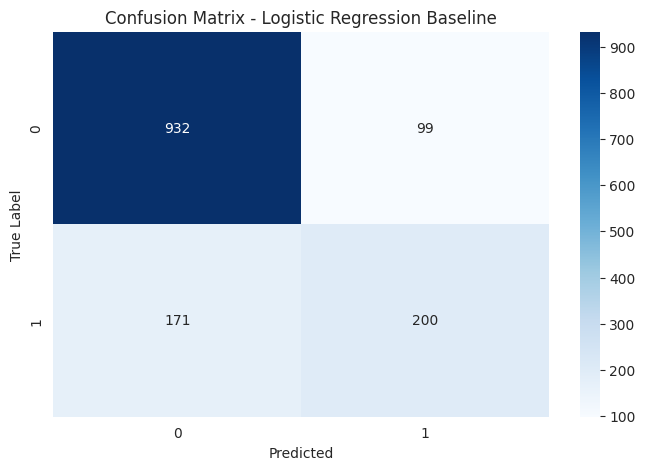

In [44]:
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.show()

## Melihat probabilitas prediksi churn

In [45]:
y_proba_baseline = baseline_model.predict_proba(X_test_processed)[:, 1]
y_proba_baseline[:10]

array([0.3689918 , 0.01291669, 0.08869964, 0.29906796, 0.25722102,
       0.45938353, 0.11084387, 0.08656549, 0.25454726, 0.18850138])

## Membandingkan hasil prediksi dan probabilitas dalam satu tabel

In [46]:
baseline_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_baseline,
    'Churn Probability': y_proba_baseline
})

baseline_results[:10]

,Actual,Predicted,Churn Probability
0,0,0,0.368992
1,0,0,0.012917
2,0,0,0.088700
3,0,0,0.299068
4,0,0,0.257221
5,1,0,0.459384
6,0,0,0.110844
7,0,0,0.086565
8,0,0,0.254547
9,0,0,0.188501


# Fase 5: Melatih XGBoost dan memahami feature importance

## Import metrik tambahan untuk perbandingan

In [47]:
from sklearn.metrics import roc_auc_score

## Membuat model XGBoost

In [48]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

## Melatih model XGBoost

In [49]:
xgb_model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

## Melakukan prediksi label dan probabilitas

In [50]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print(y_pred_xgb[:10])
print(y_proba_xgb[:10])

[0 0 0 0 0 0 0 0 0 0]
[0.3904806  0.01616674 0.08483463 0.36897498 0.26082435 0.3459079
 0.04468736 0.11590967 0.19318226 0.11128666]


## Menghitung metrik evaluasi XGBoost

In [52]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_pred_xgb)

print("Accuracy   :", xgb_accuracy)
print("Precision  :", xgb_precision)
print("Recall     :", xgb_recall)
print("f1         :", xgb_f1)
print("ROC AUC    :", xgb_roc_auc)

Accuracy   : 0.7981455064194009
Precision  : 0.6496598639455783
Recall     : 0.5148247978436657
f1         : 0.5744360902255639
ROC AUC    : 0.7074608955270704


## Menampilkan classification report XGBoost

In [53]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1031
           1       0.65      0.51      0.57       371

    accuracy                           0.80      1402
   macro avg       0.74      0.71      0.72      1402
weighted avg       0.79      0.80      0.79      1402



## Membuat dan memvisualisasikan confusion matrix XGBoost

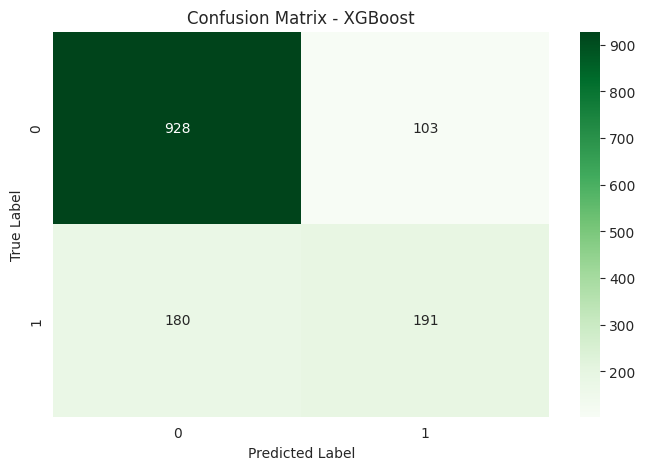

In [54]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Membandingkan baseline dan XGBoost dalam satu tabel

In [55]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    'XGBoost': [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1
    ]
})

comparison_df

,Metric,Logistic Regression,XGBoost
0,Accuracy,0.807418,0.798146
1,Precision,0.668896,0.649660
2,Recall,0.539084,0.514825
3,F1-Score,0.597015,0.574436


## Menentukan nama fitur hasil preprocessing

In [56]:
encoded_cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_features)

print("Jumlah fitur setelah preprocessing:", len(all_feature_names))
print(all_feature_names[:20])

Jumlah fitur setelah preprocessing: 45
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service']


## Mengambil feature importance dari XGBoost

In [57]:
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': xgb_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
36,Contract_Month-to-month,0.372791
16,InternetService_Fiber optic,0.103275
18,OnlineSecurity_No,0.052134
27,TechSupport_No,0.047364
38,Contract_Two year,0.036264
17,InternetService_No,0.034166
43,PaymentMethod_Electronic check,0.023364
15,InternetService_DSL,0.021475
1,tenure,0.019856
12,MultipleLines_No,0.015189


## Visualisasi 10 fitur paling penting

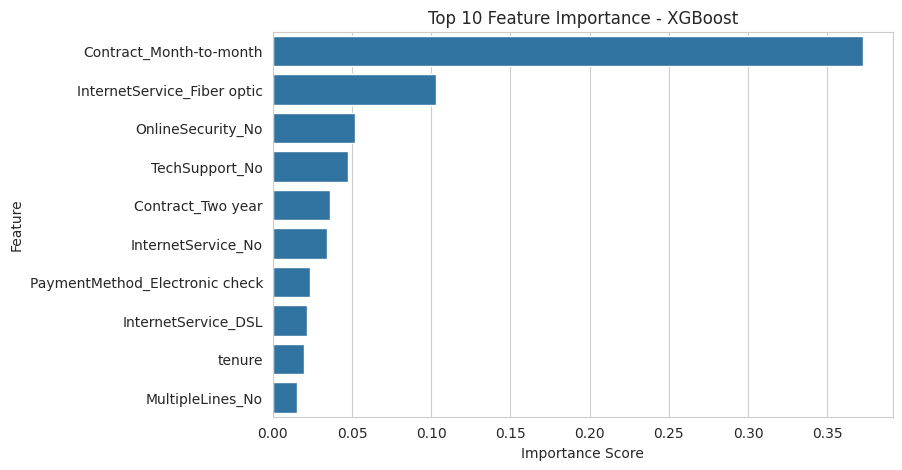

In [58]:
top_10_features = feature_importance_df.head(10)

sns.barplot(data=top_10_features, x='importance', y='feature')
plt.title('Top 10 Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Menampilkan beberapa pelanggan dengan probabilitas churn tertinggi

In [59]:
xgb_results = X_test.copy()
xgb_results['Actual'] = y_test.values
xgb_results['Predicted'] = y_pred_xgb
xgb_results['Churn_Probability'] = y_proba_xgb

xgb_results.sort_values(by='Churn_Probability', ascending=False).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Churn_Probability
2208,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,100.80,1,1,0.955115
983,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.60,86.60,1,1,0.915787
2464,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,77.15,77.15,1,1,0.913509
2745,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,86.05,86.05,1,1,0.912723
6748,Female,1,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,85.00,85.00,1,1,0.904878
4759,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,78.95,78.95,1,1,0.897885
3821,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.20,74.20,1,1,0.895007
3749,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.85,196.75,1,1,0.894359
7010,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,1,1,0.894145
1148,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.15,196.90,1,1,0.893715


# Fase 6: Menyimpan dan Mengunduh Model

Bagian ini akan mengekspor model `baseline_model` (Logistic Regression) dan `xgb_model` agar dapat digunakan di luar notebook ini.

In [60]:
import pickle
from google.colab import files

# 1. Simpan dan Unduh Logistic Regression
model_lr_path = 'logistic_regression_model.pkl'
with open(model_lr_path, 'wb') as f:
    pickle.dump(baseline_model, f)

print(f'Model Logistic Regression disimpan di: {model_lr_path}')
files.download(model_lr_path)

Model Logistic Regression disimpan di: logistic_regression_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# 2. Simpan dan Unduh XGBoost
model_xgb_path = 'xgb_model.json'
xgb_model.save_model(model_xgb_path)

print(f'Model XGBoost disimpan di: {model_xgb_path}')
files.download(model_xgb_path)

Model XGBoost disimpan di: xgb_model.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Catatan Penting**: Jangan lupa untuk menyimpan objek `preprocessor` juga. Tanpa preprocessor ini, Anda tidak akan bisa mengolah data baru (inference) dengan format yang sama seperti saat training.

In [62]:
# Simpan Preprocessor
preprocessor_path = 'preprocessor.pkl'
with open(preprocessor_path, 'wb') as f:
    pickle.dump(preprocessor, f)

files.download(preprocessor_path)
print('Preprocessor juga telah diunduh.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Preprocessor juga telah diunduh.
